In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
company_df = pd.read_csv('/datasets/project_sql_result_01.csv')

dropoff_df = pd.read_csv('/datasets/project_sql_result_04.csv')

In [4]:
company_df.head()
company_df.info()
company_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


In [5]:
dropoff_df.head()
dropoff_df.info()
dropoff_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


In [6]:
print(company_df.dtypes)

print(dropoff_df.dtypes)

company_name    object
trips_amount     int64
dtype: object
dropoff_location_name     object
average_trips            float64
dtype: object


In [8]:
top_10 = dropoff_df.sort_values(
    by='average_trips',
    ascending=False
).head(10)

print(top_10)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


In [13]:
top_companies = company_df.sort_values(
    by='trips_amount',
    ascending=False
).head(15)

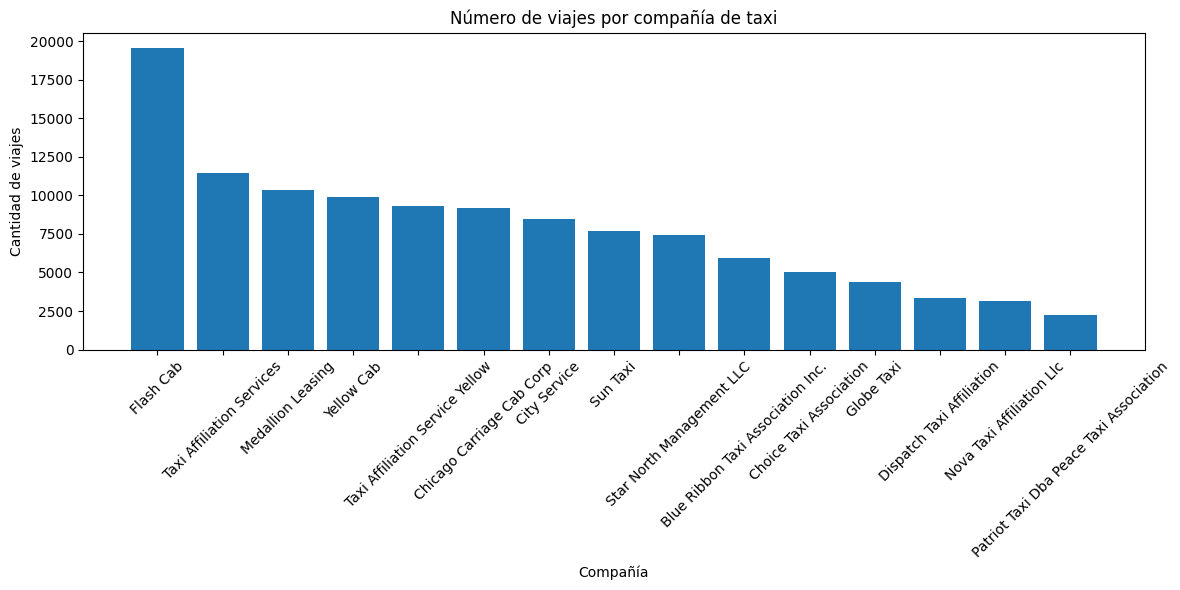

In [14]:
plt.figure(figsize=(12,6))

plt.bar(
    top_companies['company_name'],
    top_companies['trips_amount']
)

plt.xticks(rotation=45)

plt.title('Número de viajes por compañía de taxi')

plt.xlabel('Compañía')

plt.ylabel('Cantidad de viajes')

plt.tight_layout()

plt.show()



El gráfico muestra que el mercado de taxis en Chicago está dominado por unas pocas compañías. Flash Cab lidera claramente en número de viajes, superando ampliamente al resto de las empresas.
También destacan Taxi Affiliation Services y Medallion Leasing, aunque con una cantidad considerablemente menor de viajes.La diferencia entre las compañías sugiere una distribución desigual del mercado,
donde unas pocas empresas concentran la mayor parte de la demanda de transporte. Además, las compañías con menor cantidad de viajes tienen una participación mucho más reducida, lo que podría indicar menor cobertura, menor popularidad o una flota más pequeña.



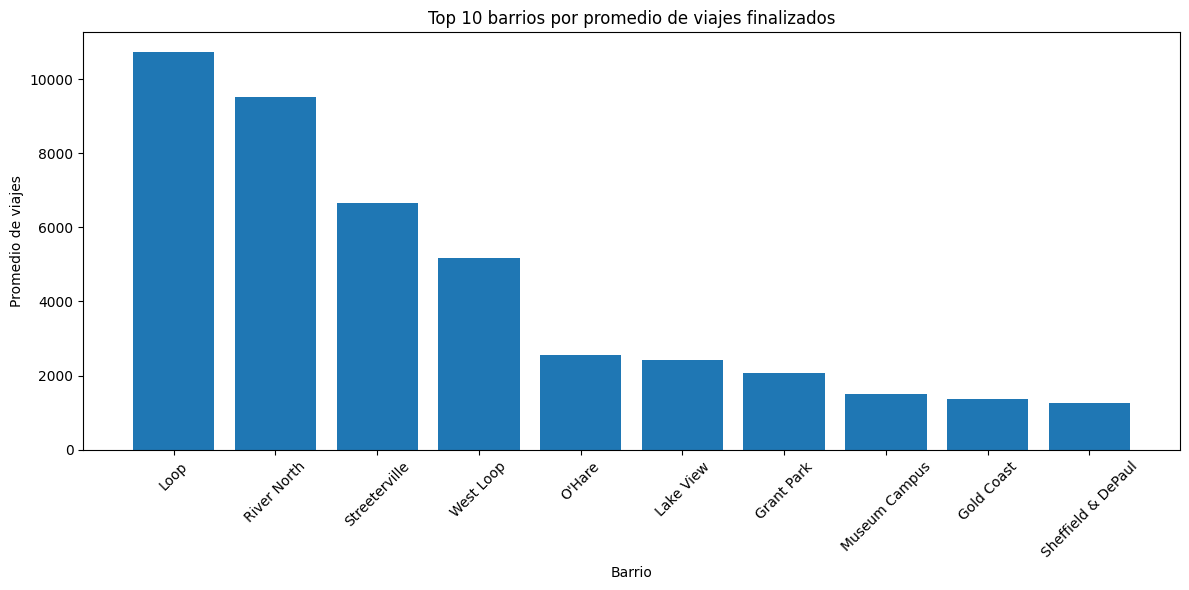

In [15]:
plt.figure(figsize=(12,6))

plt.bar(
    top_10['dropoff_location_name'],
    top_10['average_trips']
)

plt.xticks(rotation=45)

plt.title('Top 10 barrios por promedio de viajes finalizados')

plt.xlabel('Barrio')

plt.ylabel('Promedio de viajes')

plt.tight_layout()

plt.show()

El gráfico muestra que los barrios Loop y River North concentran la mayor cantidad promedio de viajes finalizados, superando ampliamente a los demás barrios. Esto indica que estas zonas representan importantes centros de actividad económica, comercial y turística en Chicago.

Streeterville y West Loop también presentan una alta demanda de viajes, aunque en menor proporción. Por otro lado, barrios como Museum Campus, Gold Coast y Sheffield & DePaul registran menos finalizaciones de trayectos en comparación con los principales destinos.

En general, los resultados sugieren que la demanda de taxis se concentra principalmente en áreas céntricas y de alta actividad urbana

In [17]:
rides_df = pd.read_csv('/datasets/project_sql_result_07.csv')

In [18]:
rides_df.head()

rides_df.info()

rides_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


,duration_seconds
count,1068.000000
mean,2071.731273
std,769.461125
min,0.000000
25%,1438.250000
50%,1980.000000
75%,2580.000000
max,7440.000000


In [19]:
rides_df['start_ts'] = pd.to_datetime(rides_df['start_ts'])

In [20]:
rides_df['weather_conditions'].unique()

array(['Good', 'Bad'], dtype=object)

In [22]:
rainy_rides = rides_df[
    rides_df['weather_conditions'] == 'Bad'
]['duration_seconds']

In [23]:
good_weather_rides = rides_df[
    rides_df['weather_conditions'] == 'Good'
]['duration_seconds']

Formular hipótesis
Hipótesis nula (H0)

La duración promedio de los viajes desde el Loop hasta el aeropuerto O'Hare es igual en sábados lluviosos y no lluviosos.

H0​: μrain​=μgood



Hipótesis alternativa (H1)

La duración promedio de los viajes cambia en sábados lluviosos.

H1: μrain != μ good


In [26]:
alpha = 0.05

Se utilizó un nivel de significación de 0.05, ya que es el valor estándar utilizado en pruebas estadísticas y permite un margen razonable de error del 5%.

In [24]:
results = stats.ttest_ind(
    rainy_rides,
    good_weather_rides,
    equal_var=False
)

print('p-value:', results.pvalue)

p-value: 6.738994326108734e-12


In [27]:
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
    print("La duración promedio de los viajes cambia en sábados lluviosos")
else:
    print("No podemos rechazar la hipótesis nula")

Rechazamos la hipótesis nula
La duración promedio de los viajes cambia en sábados lluviosos


Conclusión

Se rechaza la hipótesis nula, ya que el valor p es significativamente menor que el nivel de significación establecido (0.05).

Existe evidencia estadística suficiente para concluir que la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia durante los sábados lluviosos.

Esto sugiere que las condiciones climáticas adversas afectan significativamente el tiempo de viaje, probablemente debido a tráfico más lento, menor visibilidad y congestión vial durante la lluvia.